# Temporal Multiplex Directed Networks for the Semiconductor Industry

# LAYER 1: Returns Correlation

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt

foundries = {
    "TSM": "Taiwan Semiconductor Manufacturing Company Limited",
    "SMSN.IL": "Samsung Electronics Co., Ltd.",
    "INTC": "Intel Corporation",
    "UMC": "United Microelectronics Corporation",
    "GFS": "GlobalFoundries Inc.",
    "0981.HK": "Semiconductor Manufacturing International Corporation",
}

fabless_designers = {
    "NVDA": "NVIDIA Corporation",
    "AMD": "Advanced Micro Devices, Inc.",
    "AVGO": "Broadcom Inc.",
    "ARM": "Arm Holdings plc",
    "QCOM": "QUALCOMM Incorporated",
    "2454.TW": "MediaTek Inc.",
    "MRVL": "Marvell Technology, Inc.",
    "ALAB": "Astera Labs, Inc.",
}

memory = {
    "MU": "Micron Technology, Inc.",
    "000660.KS": "SK Hynix Inc.",
}

wfe = {
    "ASML": "ASML Holding N.V.",
    "AMAT": "Applied Materials, Inc.",
    "LRCX": "Lam Research Corporation",
    "KLAC": "KLA Corporation",
    "8035.T": "Tokyo Electron Limited",
    "6857.T": "Advantest Corporation",
    "TER": "Teradyne, Inc.",
    "6920.T": "Lasertec Corporation",
    "SNPS": "Synopsys, Inc.",
    "CDNS": "Cadence Design Systems, Inc.",
}

osat_packaging = {
    "3711.TW": "ASE Technology Holding Co., Ltd.",
    "AMKR": "Amkor Technology, Inc.",
    "042700.KS": "Hanmi Semiconductor Co., Ltd.",
}

analog_auto_power = {
    "TXN": "Texas Instruments Incorporated",
    "ADI": "Analog Devices, Inc.",
    "NXPI": "NXP Semiconductors N.V.",
    "STNE": "STMicroelectronics N.V.",
    "ON": "ON Semiconductor Corporation",
    "IFX.DE": "Infineon Technologies AG",
    "MCHP": "Microchip Technology Incorporated"
}

# Organize spheres
spheres = {
    "Foundries": foundries,
    "Fabless Designers": fabless_designers,
    "Memory": memory,
    "WFE (Equipment)": wfe,
    "OSAT & Packaging": osat_packaging,
    "Analog/Auto/Power": analog_auto_power,
}

# Download and visualize each sphere
for sphere_name, tickers_dict in spheres.items():
    data = yf.download(list(tickers_dict.keys()), start="2023-01-01", progress=False)['Close']
    
    fig = px.line(data, x=data.index, y=data.columns,
                  title=f'{sphere_name} - Close Price (Since 2023)',
                  labels={'value': 'Close Price (USD)', 'variable': 'Ticker'})
    fig.update_layout(xaxis_title='Date', yaxis_title='Price (USD)')
    fig.show()

## Stock Universe by Semiconductor Sphere

The 38-asset portfolio spans the semiconductor value chain across six interconnected tiers. Each sphere captures a distinct stage of the industry: **Foundries** (manufacturing capacity), **Fabless Designers** (chip design and AI/logic), **Memory** (DRAM and NAND), **WFE** (process equipment), **OSAT & Packaging** (assembly and test), and **Analog/Auto/Power** (peripheral components). This decomposition enables sphere-level analysis of shock propagation and contagion mechanisms across each supply-chain tier.

In [12]:
# Compute and visualize returns for each sphere
total_returns = pd.DataFrame()
for sphere_name, tickers_dict in spheres.items():
    data = yf.download(list(tickers_dict.keys()), start="2023-01-01", progress=False)['Close']
    returns = np.log(data / data.shift(1)).dropna()
    total_returns = pd.concat([total_returns, returns], axis=1)

    fig = px.line(returns, x=returns.index, y=returns.columns,
                  title=f'{sphere_name} - Returns (Since 2023)',
                  labels={'value': 'Returns', 'variable': 'Ticker'})
    fig.update_layout(xaxis_title='Date', yaxis_title='Returns')
    fig.show()

C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_23544\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_23544\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_23544\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_23544\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


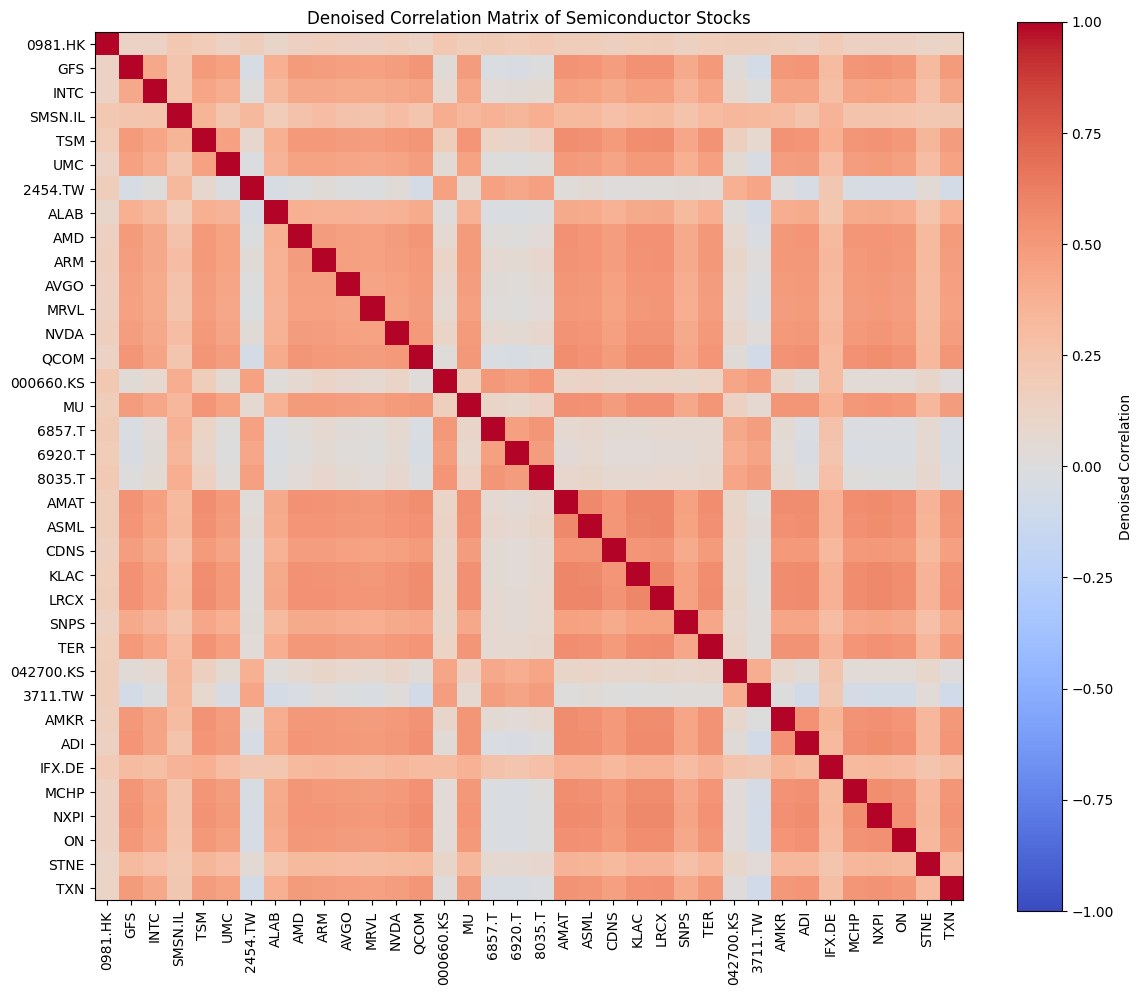

In [20]:
window = 38*1.5 #decent window size for 38 stocks, can be adjusted based on the number of stocks and desired smoothing level

corr_matrix = total_returns.corr()

# CLIPPING VALUES TO AVOID NUMERICAL INSTABILITIES (MARKET )
lambda_max = (1+np.sqrt(38/window))**2
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)

is_noise = eigenvalues < lambda_max
noise_mean = np.mean(eigenvalues[is_noise])
eigenvalues_denoised = eigenvalues.copy()
eigenvalues_denoised[is_noise] = noise_mean

C_clean = eigenvectors @ np.diag(eigenvalues_denoised) @ eigenvectors.T

d = np.diag(C_clean)
inv_std = np.diag(1 / np.sqrt(d))
C_final = inv_std @ C_clean @ inv_std
# Convert back to DataFrame with proper index and columns
C_final_df = pd.DataFrame(C_final, index=corr_matrix.index, columns=corr_matrix.columns)

C_final_df.to_csv('denoised_correlation_matrix.csv')

#visualize the denoised correlation matrix
plt.figure(figsize=(12, 10))
plt.imshow(C_final_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Denoised Correlation')
plt.title('Denoised Correlation Matrix of Semiconductor Stocks')
plt.xticks(ticks=np.arange(len(C_final_df.columns)), labels=C_final_df.columns, rotation=90) 
plt.yticks(ticks=np.arange(len(C_final_df.index)), labels=C_final_df.index)
plt.tight_layout()